<a href="https://colab.research.google.com/github/mohduzr02/DCF-MODEL/blob/main/YIntern1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
#Importing libraries like pandas ,numy, matlplotlib, and yfinance for data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date

In [104]:
# Downloading Data using yfinance using ticker AAPL for period 10 yrs
Data_1=yf.download("AAPL", period='10y',auto_adjust=True) # yf.downoad used for download , auto_ajdust adjust price for stock split , bonous share

[*********************100%***********************]  1 of 1 completed


In [105]:
# Converting data into pandas data frame, shpwing type. info
Data_1=pd.DataFrame(Data_1)
type(Data_1) ## showing data type
Data_1.shape ## showing data shape
Data_1.info() ## showing data info
Data_1.head() ## showing data head

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-07-11 to 2026-07-09
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2513 non-null   float64
 1   (High, AAPL)    2513 non-null   float64
 2   (Low, AAPL)     2513 non-null   float64
 3   (Open, AAPL)    2513 non-null   float64
 4   (Volume, AAPL)  2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
2016-07-12,22.177629,22.241371,22.109336,22.120717,96670000
2016-07-13,22.052422,22.234540,22.045591,22.175353,103568800
2016-07-14,22.489511,22.535041,22.154866,22.170802,155676000
2016-07-15,22.487228,22.605607,22.423487,22.519099,120548000


In [106]:
Data_1=Data_1.dropna()## droping null values

In [107]:
# Calculating return of the Stock using np.log function and also add return column in data_1 data frames
Data_1['Return']=np.log(Data_1['Close']/Data_1['Close'].shift(1)) ## used shift(1) jump  to next row
Data_1=Data_1.dropna() ## droping null values
Data_1.head()


Price,Close,High,Low,Open,Volume,Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2016-07-12,22.177629,22.241371,22.109336,22.120717,96670000,0.004527
2016-07-13,22.052422,22.234540,22.045591,22.175353,103568800,-0.005662
2016-07-14,22.489511,22.535041,22.154866,22.170802,155676000,0.019627
2016-07-15,22.487228,22.605607,22.423487,22.519099,120548000,-0.000102
2016-07-18,22.726263,22.794557,22.446253,22.469018,145975600,0.010574


In [108]:
# Compute and print key statistical distributions
# so, describe is used for statsitical destributing, and to_sring used to show formatted data in string
print(Data_1[['Open', 'Low', 'Close', 'Volume','Return']].describe().to_string())

Price          Open          Low        Close        Volume       Return
Ticker         AAPL         AAPL         AAPL          AAPL             
count   2512.000000  2512.000000  2512.000000  2.512000e+03  2512.000000
mean     126.986894   125.710400   127.104163  9.562811e+07     0.001060
std       78.057134    77.294699    78.128141  5.469366e+07     0.018275
min       22.041043    21.949983    22.006895  1.791060e+07    -0.137708
25%       45.799999    45.403453    45.866711  5.634982e+07    -0.007113
50%      131.843786   129.991729   131.435974  8.372580e+07     0.001095
75%      183.031723   181.401622   183.101421  1.154374e+08     0.010030
max      315.290009   310.149994   316.220001  4.479400e+08     0.142617


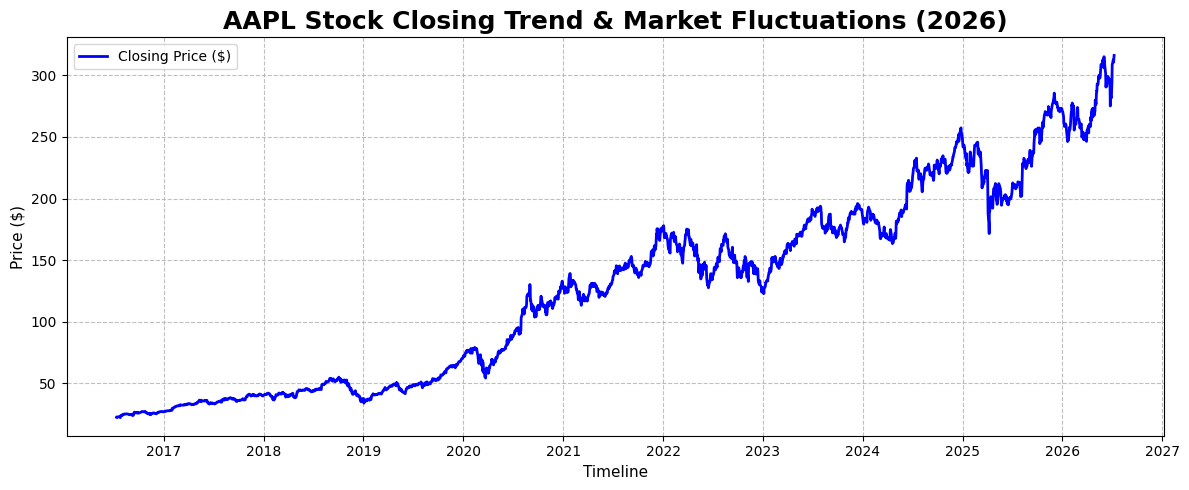

In [109]:
## Plotting and Visulalisating using matplotlib
plt.figure(figsize=(12, 5)) ## setting figure size
plt.plot(Data_1.index,Data_1['Close'],label='Closing Price ($)', color='Blue', linewidth=2) # plotting chart graph
plt.title('AAPL Stock Closing Trend & Market Fluctuations (2026)', fontsize=18, fontweight='bold') # Giving title of the Chart
plt.xlabel('Timeline', fontsize=11) # labelling X-axis
plt.ylabel('Price ($)', fontsize=11) # labelling y-axis
plt.grid(True, linestyle='--', alpha=0.8) # To show grid lines, and linestyle is -- and alpha used for tranparency
plt.legend(loc='upper left') # to show legent upper left cornor it show the label written in plt.plot(label="xyx")
plt.tight_layout() # Automatically adjusts spacing so titles, labels, and legends are less likely to overlap or get cut off.
plt.show()# used to show final graph

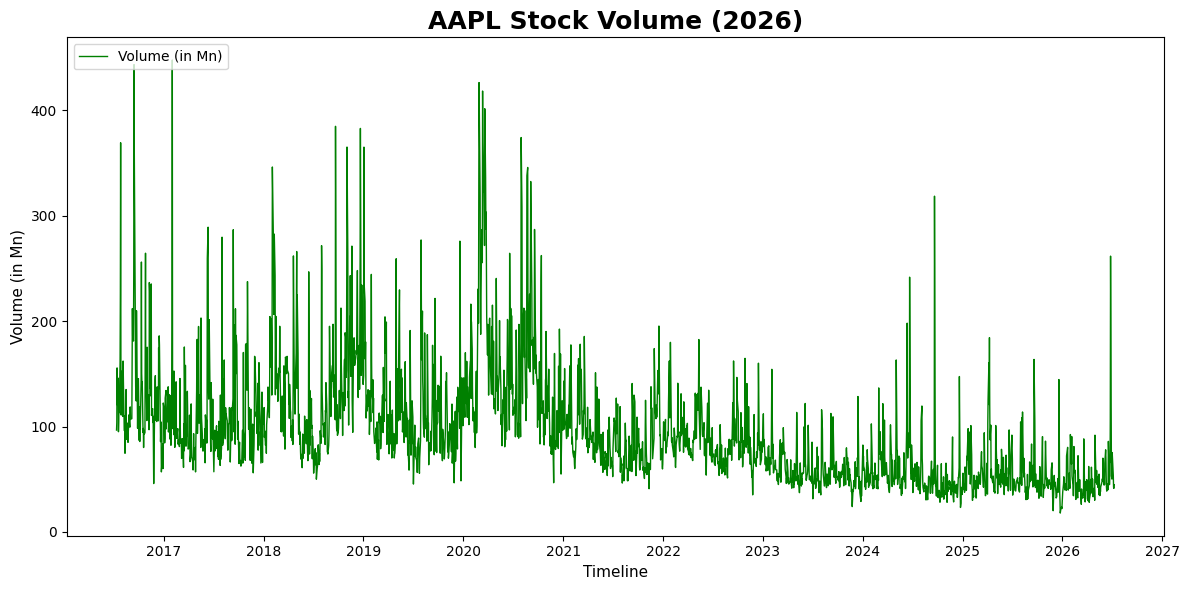

In [110]:
# Plotting graph for Volume
plt.figure(figsize=(12,6))
plt.plot(Data_1.index,Data_1['Volume']/1e6,label='Volume (in Mn)', color='Green', linewidth=1)## Data_1['Volume']/1e6 is used to convert volume in mn
plt.title('AAPL Stock Volume (2026)', fontsize=18, fontweight='bold')
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('Volume (in Mn)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


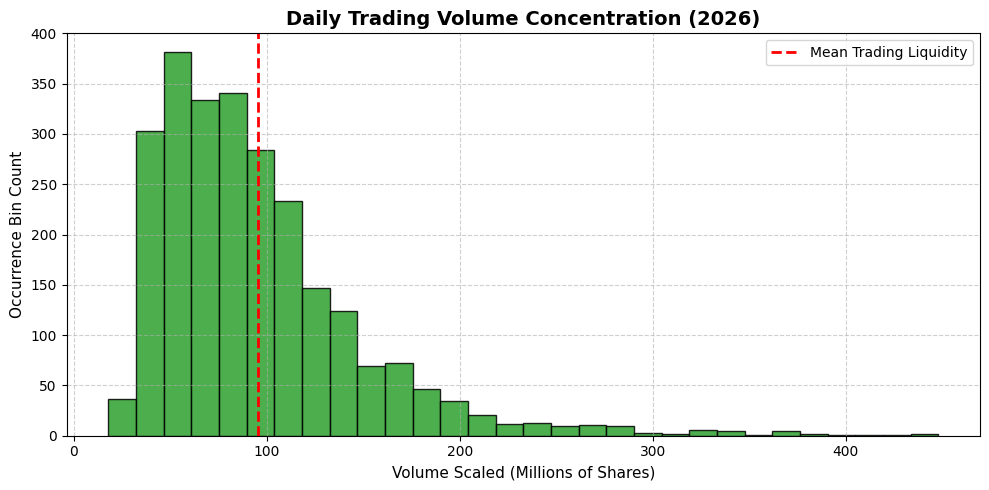

In [113]:
plt.figure(figsize=(10, 5))
plt.hist(Data_1['Volume'] / 1e6, bins=30, color='#2ca02c', edgecolor='black', alpha=0.85)# used to plot histogram
plt.axvline((Data_1['Volume'] / 1e6).mean().item(), color='red', linestyle='dashed', linewidth=2, label='Mean Trading Liquidity') # vertical red line at the average volume.
plt.title('Daily Trading Volume Concentration (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Volume Scaled (Millions of Shares)', fontsize=11)
plt.ylabel('Occurrence Bin Count', fontsize=11)## how many days fell into each volume range
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()